## Clustering Algorithms Exercise

We aim to implement k-means clustering, fuzzy k-means clustering, and expectation-maximization on the data.

We use k = 3 on the Optdigits features. We will calculate and plot the reconstruction error E(n) for different values of n.

### Imports, Data, and Helper Setup

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cm as cm
from scipy.stats import multivariate_normal

In [10]:
data = np.loadtxt("unsupervised_learning_data.txt", delimiter=",")
display(data)

array([[  3.38395,   0.12138],
       [ -0.07015,  -0.09825],
       [  1.50434,  -0.24863],
       ...,
       [ -3.81001, -14.80439],
       [  1.06136,  -2.17322],
       [ -4.37691,  -4.5265 ]])

In [36]:
def plot_covariance_ellipse(mean, covariance_matrix, ax):
  eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

  sorted_eigenvalues_idx = np.argsort(eigenvalues)[::-1]

  eigenvalues = eigenvalues[sorted_eigenvalues_idx]
  eigenvectors = eigenvectors[:, sorted_eigenvalues_idx]

  # Angle the ellipse according to the top eigenvalues/vectors
  angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

  # Based on the 1/e ellipse as per the text
  width, height = 2 * np.sqrt(2.0) * np.sqrt(eigenvalues)

  ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, 
                    edgecolor="black", fc="None", lw=2, linestyle="--")
  ax.add_patch(ellipse)

def plot_results_multi_k(data, algorithm_name, k, memberships, means, covariances = None):
  """
  Plots the following:
  - resulting membership sets
  - estimated means
  - estimated covariances (where applicable)
  
  Includes blended membership with colors.
  """
  _, ax = plt.subplots(figsize=(6, 6))

  # "Make sure the coordinate axes are scaled equally"
  ax.set_aspect("equal")
  ax.set_title(plot_title := f"{algorithm_name} with k={k}")

  # Generate colors. To generalize this for fuzzy blending, 
  # use dot product with membership values
  colors = np.dot(memberships, cm.rainbow(np.linspace(0, 1, k))[:, :3])
  
  # Plot points with fuzzy colors
  ax.scatter(data[:, 0], data[:, 1], c=colors, alpha=0.7)
  
  for i, mean in enumerate(means):
    ax.scatter(mean[0], mean[1], c="black", marker="o", edgecolors="white")

    if covariances is not None:
        plot_covariance_ellipse(mean, covariances[i], ax)

  plt.savefig(f"{plot_title}.png")

  plt.show()

def print_parameters(algorithm_name, k, means, covariances = None):
    print(f"{algorithm_name} Parameters with k={k}:")
    print(f"Means: {means}")
    if covariances is not None:
       print(f"Covariances: {covariances}")

### Normal k-means clustering

In [24]:
def run_normal_kmeans(data, k):
  n = data.shape[0]
  means = data[np.random.choice(n, k, replace=False)]

  # Cap at 100 iterations
  for _ in range(100):
    distances = np.linalg.norm(data[:, np.newaxis] - means, axis=2)**2
    cluster_assignments = np.argmin(distances, axis=1)
    
    new_means = np.zeros_like(means)
    for i in range(k):
      points = data[cluster_assignments == i]
      if len(points) > 0:
        new_means[i] = np.mean(points, axis=0)
            
    if np.all(means == new_means):
      break
    means = new_means
      
  memberships = np.zeros((n, k))
  memberships[np.arange(n), cluster_assignments] = 1
  
  return memberships, means

### Fuzzy k-means clustering 

In [ ]:
def run_fuzzy_kmeans(data, k):
  b = 2

  n, d = data.shape
  memberships = np.random.rand(n, k)
  
  # Normalize initial random memberships
  memberships /= np.sum(memberships, axis=1, keepdims=True)
  means = np.zeros((k, d))

  # Cap at 100 iterations
  for _ in range(100):
    old_memberships = memberships.copy()
    blended_weights = memberships ** b
    
    # Update means using graded/fuzzy memberships
    for i in range(k):
      means[i] = np.sum(blended_weights[:, i:i+1] * data, axis=0) / np.sum(blended_weights[:, i])
        
    distances = np.linalg.norm(data[:, np.newaxis] - means, axis=2)**2
    distances = np.fmax(distances, np.finfo(np.float64).eps) 
    
    # Update memberships using inverse distances
    inv_distances = (1.0 / distances) ** (1.0 / (b - 1.0))
    memberships = inv_distances / np.sum(inv_distances, axis=1, keepdims=True)

    # Use 1e-5 as threshold for "small change"
    if np.max(np.abs(memberships - old_memberships)) < 1e-5:
      break
          
  return memberships, means

### Expectation-Maximization

In [34]:
def run_expectation_maximization(data, k):
  n, d = data.shape
  means = data[np.random.choice(n, k, replace=False)]
  priors = np.ones(k) / k
  covariances = np.array([np.eye(d) for _ in range(k)]) 
  log_likelihood = 0

  # Cap at 100 iterations
  for _ in range(100):
    # E step: Compute posterior membership probabilities (Q)
    memberships = np.zeros((n, k))
    for i in range(k):
      rv = multivariate_normal(means[i], covariances[i], allow_singular=True)
      memberships[:, i] = priors[i] * rv.pdf(data)
        
    marginal = np.sum(memberships, axis=1, keepdims=True)
    new_log_likelihood = np.sum(np.log(marginal))
    memberships /= marginal
    
    # M step: Update parameters (argmax Q)
    N_k = np.sum(memberships, axis=0)
    priors = N_k / n
    
    for i in range(k):
      means[i] = np.sum(memberships[:, i:i+1] * data, axis=0) / N_k[i]
      diff = data - means[i]
      covariances[i] = np.dot((memberships[:, i:i+1] * diff).T, diff) / N_k[i]
      covariances[i] += np.eye(d) * 1e-6 

    # Use 1e-5 as threshold for "small change"
    if np.abs(new_log_likelihood - log_likelihood) < 1e-5:
      break
    log_likelihood = new_log_likelihood
      
  return memberships, means, covariances

### Run and report

Normal k-means clustering Parameters with k=2:
Means: [[-5.0701706   4.58121849]
 [-0.14456814 -1.85542513]]


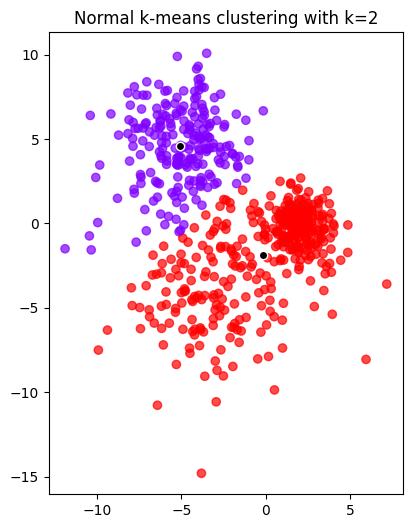

Fuzzy k-means clustering Parameters with k=2:
Means: [[-4.98068681  3.99560075]
 [ 0.49485976 -1.47463178]]


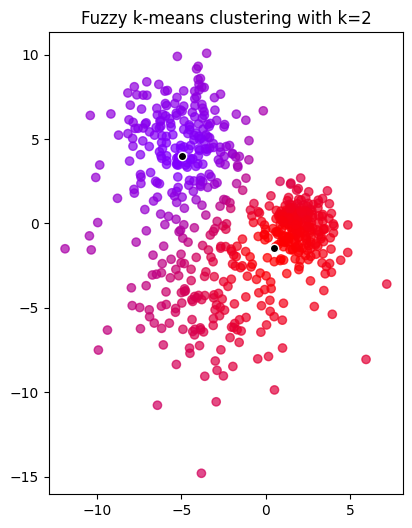

Expectation-Maximization Parameters with k=2:
Means: [[-0.12499783 -1.84099009]
 [-5.05027637  4.48631205]]
Covariances: [[[9.3503205  4.69357233]
  [4.69357233 7.66717327]]

 [[3.91746644 0.53951181]
  [0.53951181 5.70370659]]]


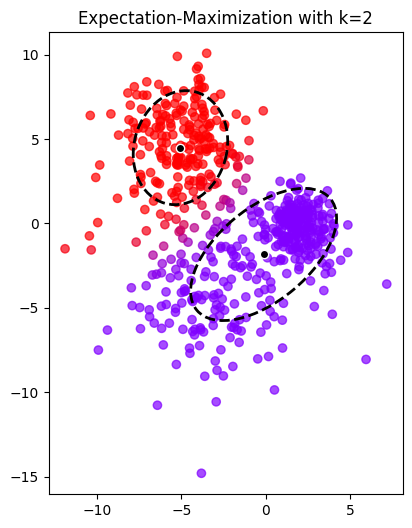

Normal k-means clustering Parameters with k=3:
Means: [[-3.85168321 -4.43789157]
 [ 1.71574964 -0.38510952]
 [-4.93770038  4.74879816]]


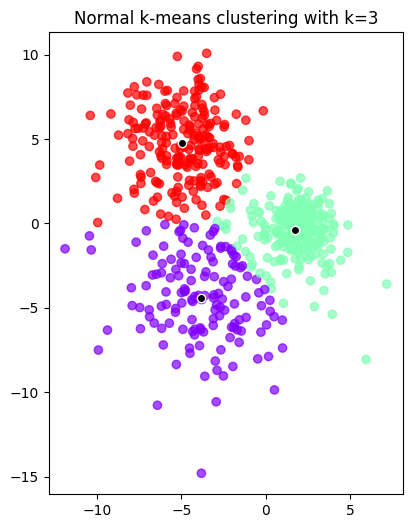

Fuzzy k-means clustering Parameters with k=3:
Means: [[ 1.69455619 -0.30192546]
 [-5.00761861  4.93426968]
 [-3.84523755 -4.49281404]]


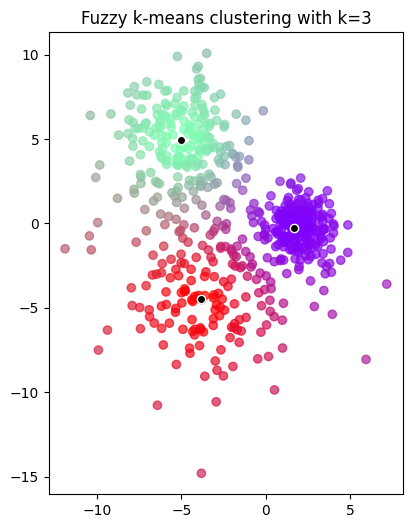

Expectation-Maximization Parameters with k=3:
Means: [[-4.86270935  4.88194017]
 [-3.00784756 -3.40676601]
 [ 1.95597565 -0.14706473]]
Covariances: [[[ 3.484975   -0.35395577]
  [-0.35395577  4.14698841]]

 [[ 9.46008194 -0.34430142]
  [-0.34430142  9.14356992]]

 [[ 1.02652326 -0.12595407]
  [-0.12595407  1.14108967]]]


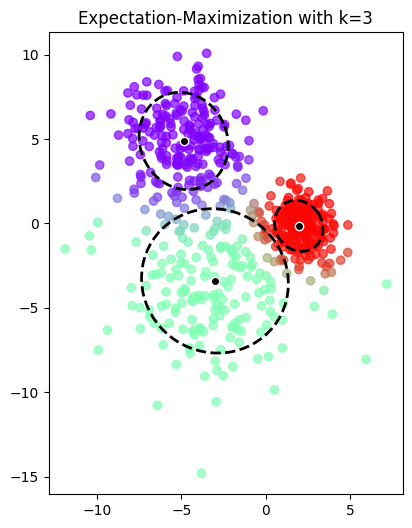

Normal k-means clustering Parameters with k=5:
Means: [[ 1.94252668 -0.21148592]
 [-4.88198027 -5.39910904]
 [-4.97302022  1.47593935]
 [-4.88185764  5.8055498 ]
 [-0.89513    -4.121535  ]]


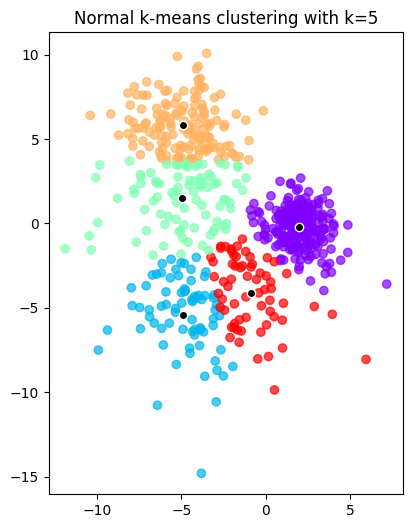

Fuzzy k-means clustering Parameters with k=5:
Means: [[-4.25280954 -5.4639312 ]
 [-5.31466155  6.27909943]
 [-4.58891976  3.15491342]
 [-1.68666442 -2.37195032]
 [ 1.97219672 -0.15755499]]


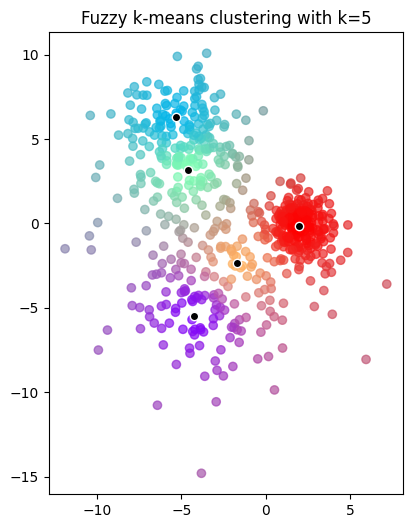

Expectation-Maximization Parameters with k=5:
Means: [[-3.10202039 -3.4071335 ]
 [ 1.22646759  0.48052881]
 [ 2.61708483 -0.38348752]
 [-4.86963604  4.91168345]
 [ 1.5064332  -0.09278343]]
Covariances: [[[ 9.03753193 -0.48228743]
  [-0.48228743  9.26912991]]

 [[ 3.20045113 -0.49263613]
  [-0.49263613  0.14098531]]

 [[ 0.75226849 -0.28380516]
  [-0.28380516  1.70348442]]

 [[ 3.4772416  -0.3250633 ]
  [-0.3250633   4.05882648]]

 [[ 0.48017742  0.14220415]
  [ 0.14220415  0.87264155]]]


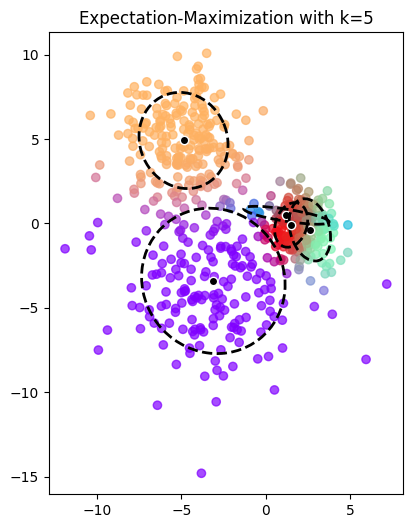

Normal k-means clustering Parameters with k=10:
Means: [[-1.96483327 -2.32509885]
 [-5.73217304 -4.3066813 ]
 [-6.76311973  0.9050927 ]
 [ 2.8410153  -1.81317303]
 [-3.85806022  7.13569178]
 [-4.59374458  4.30431797]
 [-7.10258468  6.05212426]
 [-2.32064587 -6.97667326]
 [ 1.61539537  0.27741198]
 [-2.71054325  2.790055  ]]


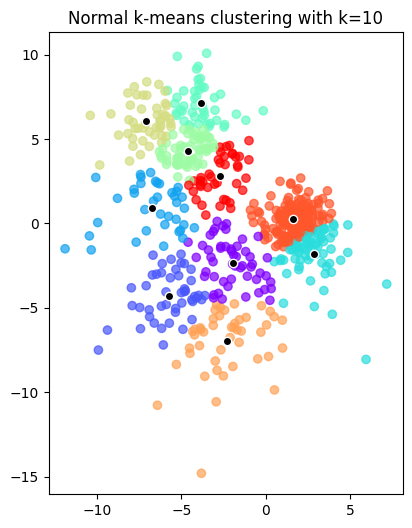

Fuzzy k-means clustering Parameters with k=10:
Means: [[ 2.17262414 -1.6369886 ]
 [-2.21569463 -2.07382455]
 [-3.82492072  4.13792416]
 [-2.40184344 -6.44631822]
 [ 1.13504421  0.1599309 ]
 [-5.55516021  1.46509976]
 [-4.24668119  7.00853328]
 [-6.86870428  5.65985257]
 [ 2.53113623  0.35177248]
 [-5.46863279 -4.54589472]]


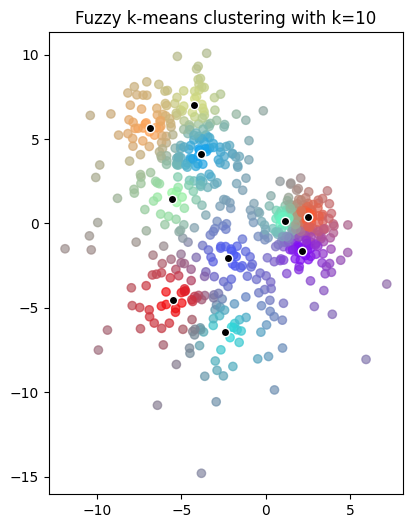

Expectation-Maximization Parameters with k=10:
Means: [[-4.43464577  3.05537349]
 [ 1.41279538 -0.8337984 ]
 [ 1.41120833  0.23933319]
 [-3.96385623  8.24839754]
 [ 2.61105147 -0.37772342]
 [ 1.9007975   0.57689323]
 [-1.31904518 -2.29339462]
 [ 3.49617969 -3.31720613]
 [-5.04110382  5.24739238]
 [-4.06916882 -3.85560655]]
Covariances: [[[ 3.25043185  1.01722603]
  [ 1.01722603  2.04421679]]

 [[ 2.33710443 -1.27853178]
  [-1.27853178  1.48474147]]

 [[ 0.1726088   0.18217969]
  [ 0.18217969  1.49595113]]

 [[ 0.04610313  0.11777897]
  [ 0.11777897  0.83630326]]

 [[ 0.72024653  0.1144475 ]
  [ 0.1144475   0.55199211]]

 [[ 0.64366063  0.2771667 ]
  [ 0.2771667   0.30519448]]

 [[ 1.5507762  -1.89825054]
  [-1.89825054  2.70633115]]

 [[ 4.1600422  -2.8260726 ]
  [-2.8260726   6.37608483]]

 [[ 3.62009986 -0.68906878]
  [-0.68906878  2.63849816]]

 [[ 6.45156556 -1.94586872]
  [-1.94586872  9.60632604]]]


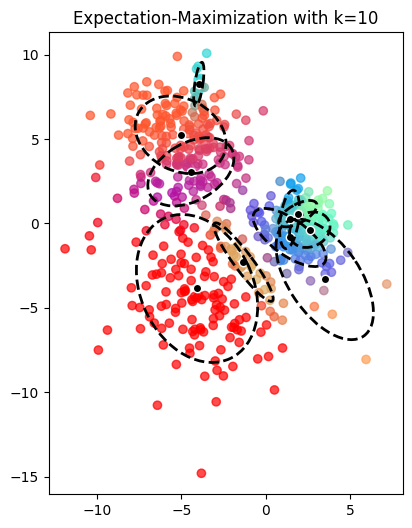

In [37]:
k_values = [2, 3, 5, 10]

for k in k_values:  
  # Normal k-means clustering
  memberships_nkm, means_nkm = run_normal_kmeans(data, k)
  print_parameters(nkm_string := "Normal k-means clustering", k, means_nkm)
  plot_results_multi_k(data, nkm_string, k, memberships_nkm, means_nkm)
  
  # Fuzzy k-means clustering
  memberships_fkm, means_fkm = run_fuzzy_kmeans(data, k)
  print_parameters(fkm_string := "Fuzzy k-means clustering", k, means_fkm)
  plot_results_multi_k(data, fkm_string, k, memberships_fkm, means_fkm)
  
  # Expectation-Maximization
  memberships_em, means_em, covariances_em = run_expectation_maximization(data, k)
  print_parameters(em_string := "Expectation-Maximization", k, means_em, covariances_em)
  plot_results_multi_k(data, em_string, k, memberships_em, means_em, covariances_em)